# Time Series Data and Embeddings

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

In [228]:
def plot_arrow_chart(
    dataframe: pd.DataFrame,
    x_col: str,
    y_col: str,
    ax: plt.Axes,
    color: str = "k",
    alpha: float = 0.7,
    marker: str = ".",
    linestyle: str = "-",
    arrow_head_width: int = 4000,
) -> plt.Axes:
    """
    Plot an arrow chart for the 'Total' and its lagged values
    within a specified date range.
    """

    x = dataframe[x_col].values
    y = dataframe[y_col].values

    ax.plot(x, y, marker=marker, linestyle=linestyle, color=color, alpha=alpha)

    step = max(1, len(x) // 100)
    for i in range(0, len(x) - 1, step):
        ax.arrow(
            x[i],
            y[i],
            x[i + 1] - x[i],
            y[i + 1] - y[i],
            shape="full",
            lw=0,
            length_includes_head=True,
            head_width=arrow_head_width,
            color=color,
            alpha=alpha,
        )

    return ax

## Pendulum

In [221]:
from ts_dl_utils.datasets.pendulum import Pendulum

In [248]:
pen = Pendulum(length=20)

df_pen = pd.DataFrame(pen(3, 100, initial_angle=1, beta=0.01))

df_pen["theta_1"] = df_pen["theta"].shift()
df_pen["theta_diff"] = df_pen["theta"].diff()

df_pen

,t,theta,theta_1,theta_diff
0,0.000000,1.000000,NaN,NaN
1,0.089714,0.997132,1.000000,-0.002868
2,0.179428,0.990336,0.997132,-0.006796
3,0.269142,0.979647,0.990336,-0.010689
4,0.358856,0.965114,0.979647,-0.014533
...,...,...,...,...
295,26.465639,0.729907,0.714216,0.015691
296,26.555353,0.742692,0.729907,0.012785
297,26.645067,0.752524,0.742692,0.009833
298,26.734781,0.759371,0.752524,0.006847


/var/folders/gk/cdkvr2rn1yn547mssh0ccq4c0000gp/T/ipykernel_55794/4179391181.py:45: UserWarning:

The figure layout has changed to tight



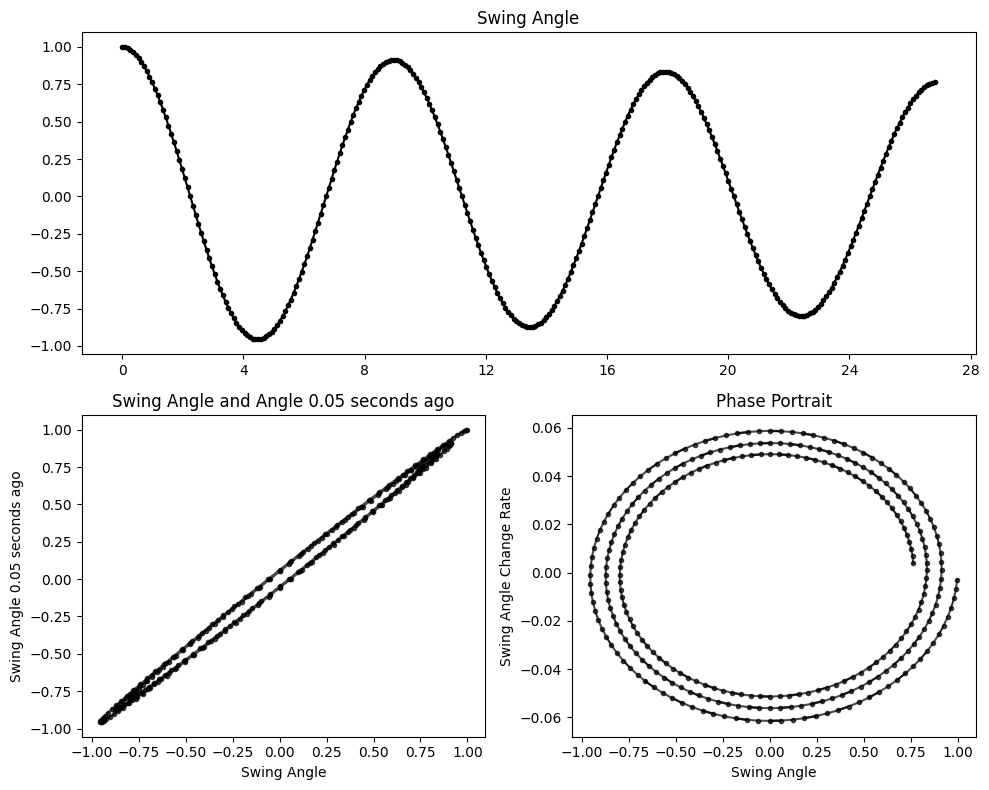

In [254]:
fig = plt.figure(figsize=(10, 8), layout="constrained")
spec = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(spec[0, :])
ax10 = fig.add_subplot(spec[1, 0])
ax11 = fig.add_subplot(spec[1, 1])

ax0.plot(
    df_pen.t,
    df_pen.theta,
    marker=".",
    linestyle="-",
    color="k",
)
# Make x-ticks readable
ax0.xaxis.set_major_locator(plt.MaxNLocator(8))
# fig.autofmt_xdate(rotation=30)
ax0.set_title("Swing Angle")


ax10 = plot_arrow_chart(
    df_pen, x_col="theta", y_col="theta_1", ax=ax10, arrow_head_width=0.00001
)
ax10.set_xlabel("Swing Angle")
ax10.set_ylabel("Swing Angle 0.05 seconds ago")
ax10.set_title("Swing Angle and Angle 0.05 seconds ago")


ax11 = plot_arrow_chart(
    df_pen, x_col="theta", y_col="theta_diff", ax=ax11, arrow_head_width=0.00001
)

ax11.set_xlabel("Swing Angle")
ax11.set_ylabel("Swing Angle Change Rate")
ax11.set_title("Phase Portrait")

plt.tight_layout()

## Covid

In [6]:
df_ecdc_covid = pd.read_csv(
    "https://gist.githubusercontent.com/emptymalei/"
    "90869e811b4aa118a7d28a5944587a64/raw"
    "/1534670c8a3859ab3a6ae8e9ead6795248a3e664"
    "/ecdc%2520covid%252019%2520data"
)

In [10]:
px.line(df_ecdc_covid, x="datetime", y="Total")

In [86]:
df_ecdc_covid

,datetime,AT,BE,BG,CY,CZ,DE,DK,EE,ES,...,MT,NL,NO,PL,PT,RO,SE,SI,SK,Total
0,2020-03-20,550.0,309.0,13.0,0.0,172.0,5940.0,36.0,9.0,3431.0,...,5.0,409.0,129.0,68.0,143.0,17.0,122.0,33.0,16.0,19780.0
1,2020-03-21,453.0,462.0,22.0,9.0,210.0,4185.0,104.0,16.0,2833.0,...,11.0,534.0,190.0,70.0,235.0,31.0,200.0,22.0,14.0,18412.0
2,2020-03-22,375.0,558.0,36.0,17.0,91.0,3140.0,71.0,23.0,4946.0,...,9.0,637.0,184.0,111.0,260.0,59.0,123.0,42.0,41.0,20797.0
3,2020-03-23,607.0,586.0,22.0,11.0,170.0,3311.0,69.0,20.0,3646.0,...,17.0,573.0,206.0,98.0,320.0,66.0,160.0,31.0,7.0,18375.0
4,2020-03-24,855.0,342.0,16.0,21.0,71.0,4438.0,65.0,26.0,4517.0,...,17.0,545.0,239.0,115.0,460.0,143.0,110.0,28.0,6.0,22237.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,2020-12-10,2913.0,3071.0,3328.0,363.0,6406.0,23679.0,2558.0,544.0,9773.0,...,79.0,6524.0,459.0,12166.0,7002.0,7365.0,7061.0,2137.0,2564.0,158702.0
266,2020-12-11,2466.0,2754.0,3075.0,403.0,5872.0,29875.0,3132.0,544.0,7955.0,...,106.0,8709.0,362.0,13750.0,3134.0,7067.0,7935.0,1848.0,3125.0,172457.0
267,2020-12-12,3026.0,2762.0,3097.0,424.0,6217.0,28438.0,3075.0,358.0,10519.0,...,96.0,8827.0,498.0,13105.0,5080.0,6460.0,7370.0,1816.0,2166.0,172804.0
268,2020-12-13,2938.0,0.0,1287.0,324.0,3657.0,20200.0,3552.0,757.0,0.0,...,121.0,9071.0,0.0,11499.0,4413.0,6333.0,0.0,1744.0,0.0,135594.0


In [196]:
df_ecdc_covid_arrow_chart = df_ecdc_covid.loc[
    pd.to_datetime(df_ecdc_covid.datetime).between("2020-08-01", "2020-12-01")
].copy()

df_ecdc_covid_arrow_chart["Total_1"] = df_ecdc_covid_arrow_chart["Total"].shift()
df_ecdc_covid_arrow_chart["Total_diff"] = df_ecdc_covid_arrow_chart["Total"].diff()

/var/folders/gk/cdkvr2rn1yn547mssh0ccq4c0000gp/T/ipykernel_55794/2305141229.py:44: UserWarning:

The figure layout has changed to tight



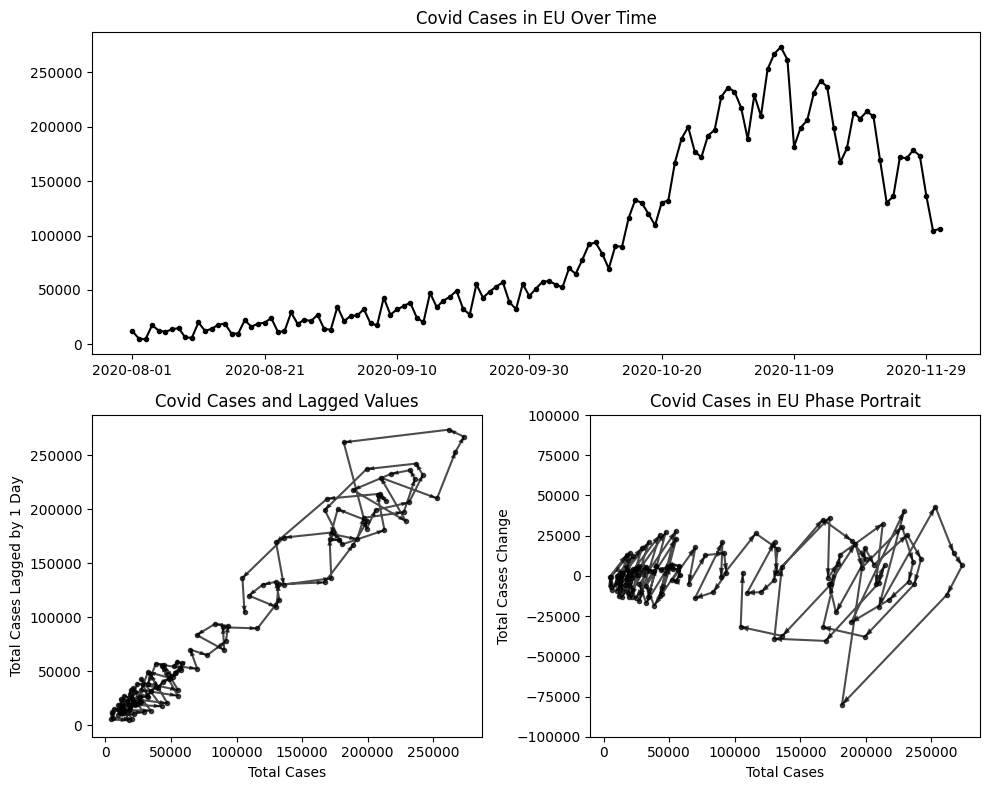

In [219]:
fig = plt.figure(figsize=(10, 8), layout="constrained")
spec = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(spec[0, :])
ax10 = fig.add_subplot(spec[1, 0])
ax11 = fig.add_subplot(spec[1, 1])

ax0.plot(
    df_ecdc_covid_arrow_chart.datetime,
    df_ecdc_covid_arrow_chart.Total,
    marker=".",
    linestyle="-",
    color="k",
)
# Make x-ticks readable
ax0.xaxis.set_major_locator(plt.MaxNLocator(8))
# fig.autofmt_xdate(rotation=30)
ax0.set_title("Covid Cases in EU Over Time")


ax10 = plot_arrow_chart(
    df_ecdc_covid_arrow_chart, x_col="Total", y_col="Total_1", ax=ax10
)
ax10.set_xlabel("Total Cases")
ax10.set_ylabel("Total Cases Lagged by 1 Day")
ax10.set_title("Covid Cases and Lagged Values")


ax11 = plot_arrow_chart(
    df_ecdc_covid_arrow_chart, x_col="Total", y_col="Total_diff", ax=ax11
)

ax11.set_xlabel("Total Cases")
ax11.set_ylabel("Total Cases Change")
ax11.set_title("Covid Cases in EU Phase Portrait")
ax11.set_ylim(-100_000, 100_000)

plt.tight_layout()

## Walmart

In [14]:
df_walmart = pd.read_csv(
    "https://raw.githubusercontent.com/datumorphism/"
    "dataset-m5-simplified/refs/heads/main/dataset/"
    "m5_store_sales.csv"
)

In [12]:
df_walmart

,date,CA,TX,WI,"('CA', 'CA_1')","('CA', 'CA_2')","('CA', 'CA_3')","('CA', 'CA_4')","('TX', 'TX_1')","('TX', 'TX_2')","('TX', 'TX_3')","('WI', 'WI_1')","('WI', 'WI_2')","('WI', 'WI_3')"
0,2011-01-29,14195,9438,8998,4337,3494,4739,1625,2556,3852,3030,2704,2256,4038
1,2011-01-30,13805,9630,8314,4155,3046,4827,1777,2687,3937,3006,2194,1922,4198
2,2011-01-31,10108,6778,6897,2816,2121,3785,1386,1822,2731,2225,1562,2018,3317
3,2011-02-01,11047,7381,6984,3051,2324,4232,1440,2258,2954,2169,1251,2522,3211
4,2011-02-02,9925,5912,3309,2630,1942,3817,1536,1694,2492,1726,2,1175,2132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1908,2016-04-20,15148,9600,10595,3722,3691,5235,2500,2901,3384,3315,3242,4194,3159
1909,2016-04-21,14488,9602,10943,3709,3303,5018,2458,2776,3446,3380,3324,4393,3226
1910,2016-04-22,17095,10615,12807,4387,4457,5623,2628,3022,3902,3691,3991,4988,3828
1911,2016-04-23,21834,12266,14862,5577,5884,7419,2954,3700,4483,4083,4772,5404,4686


In [13]:
px.line(df_walmart, x="date", y="CA")

In [27]:
df_walmart_total = df_walmart[["date", "CA", "TX", "WI"]].copy()

In [45]:
df_walmart_total["total"] = (
    df_walmart_total.CA + df_walmart_total.TX + df_walmart_total.WI
)

df_walmart_total["datetime"] = pd.to_datetime(df_walmart_total.date, format="%Y-%m-%d")
df_walmart_total["timestamp"] = df_walmart_total.datetime.astype(int) // 10**9

In [208]:
df_walmart_total["total_1"] = df_walmart_total.total.shift()
df_walmart_total["total_diff"] = df_walmart_total.total.diff()

In [209]:
px.scatter(
    df_walmart_total.loc[pd.to_datetime(df_walmart_total.date).dt.year == 2016],
    x="total",
    y="total_1",
    color="timestamp",
)

In [ ]:
df_walmart_arrow_chart = df_walmart_total.loc[
    pd.to_datetime(df_walmart_total.date).between("2016-01-01", "2016-03-01")
].copy()

/var/folders/gk/cdkvr2rn1yn547mssh0ccq4c0000gp/T/ipykernel_55794/2550651657.py:43: UserWarning:

The figure layout has changed to tight



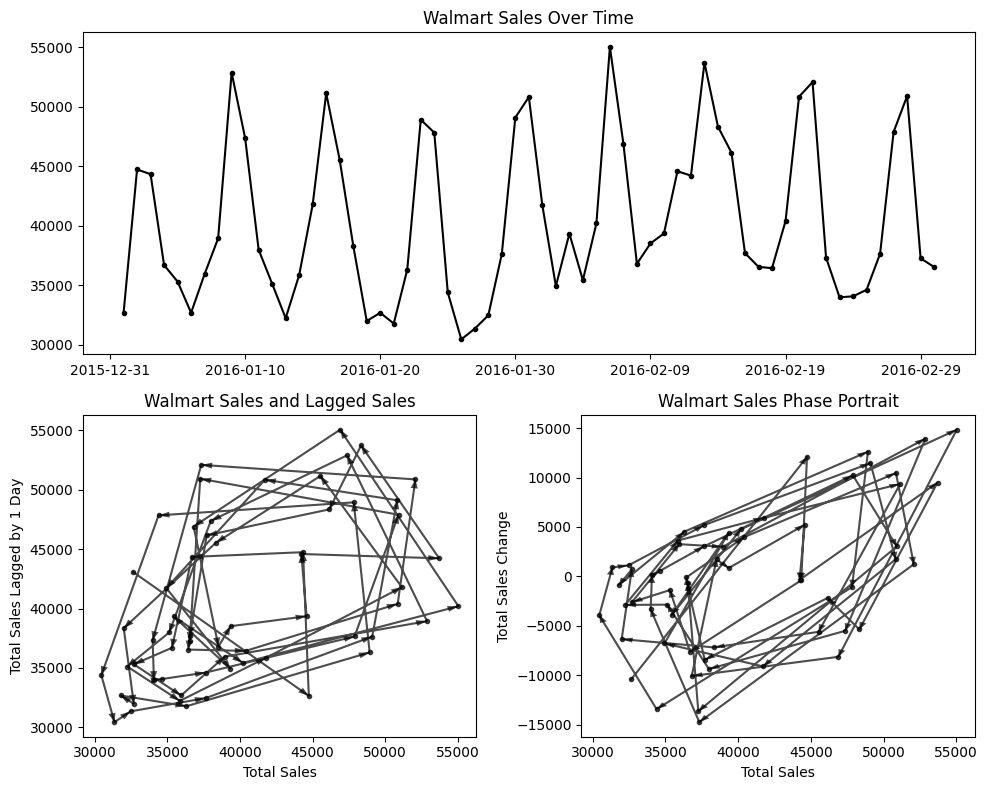

In [214]:
fig = plt.figure(figsize=(10, 8), layout="constrained")
spec = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(spec[0, :])
ax10 = fig.add_subplot(spec[1, 0])
ax11 = fig.add_subplot(spec[1, 1])

ax0.plot(
    df_walmart_arrow_chart.datetime,
    df_walmart_arrow_chart.total,
    marker=".",
    linestyle="-",
    color="k",
)
# Make x-ticks readable
ax0.xaxis.set_major_locator(plt.MaxNLocator(8))
# fig.autofmt_xdate(rotation=30)
ax0.set_title("Walmart Sales Over Time")

ax10 = plot_arrow_chart(
    df_walmart_arrow_chart,
    x_col="total",
    y_col="total_1",
    ax=ax10,
    arrow_head_width=500,
)
ax10.set_xlabel("Total Sales")
ax10.set_ylabel("Total Sales Lagged by 1 Day")
ax10.set_title("Walmart Sales and Lagged Sales")

ax11 = plot_arrow_chart(
    df_walmart_arrow_chart,
    x_col="total",
    y_col="total_diff",
    ax=ax11,
    arrow_head_width=500,
)
ax11.set_xlabel("Total Sales")
ax11.set_ylabel("Total Sales Change")
ax11.set_title("Walmart Sales Phase Portrait")


plt.tight_layout()

## Electricity Data

In [93]:
import io
import zipfile

In [ ]:
import pandas as pd

In [ ]:
import requests

# Download from remote URL
data_uri = "https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip"

r = requests.get(data_uri)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("tmp/data/uci_electricity/")


In [96]:
# Load as pandas dataframe
df_electricity = (
    pd.read_csv("tmp/data/uci_electricity/LD2011_2014.txt", delimiter=";", decimal=",")
    .rename(columns={"Unnamed: 0": "date"})
    .set_index("date")
)
df_electricity.index = pd.to_datetime(df_electricity.index)

In [99]:
df_electricity

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
date,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865


<Axes: xlabel='date'>

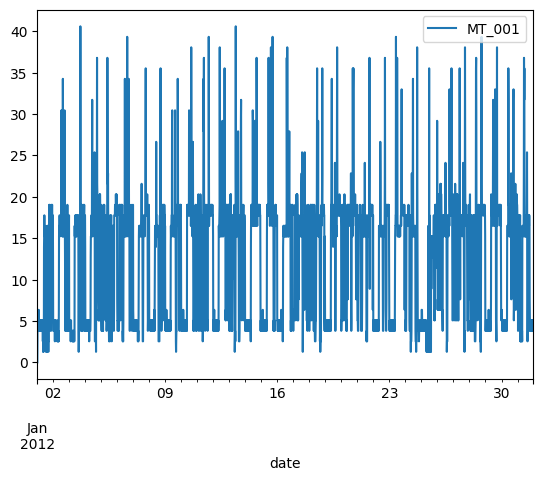

In [107]:
df_electricity.loc[
    (df_electricity.index >= "2012-01-01") & (df_electricity.index < "2012-02-01")
][["MT_001"]].plot()